In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving IRIS.csv to IRIS.csv
User uploaded file "IRIS.csv" with length 4617 bytes


First 5 rows:
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

Base Model Accuracy: 1.0

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Tuned Model Accuracy: 0.9666666666666667


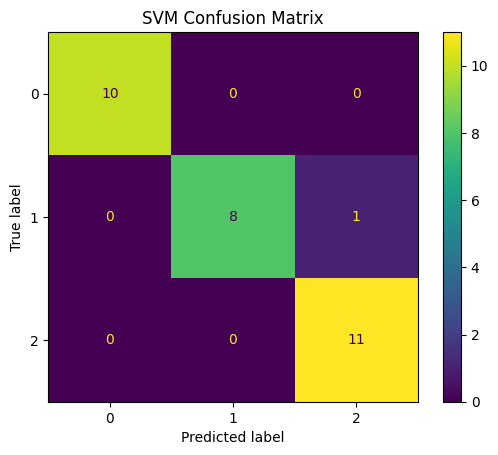

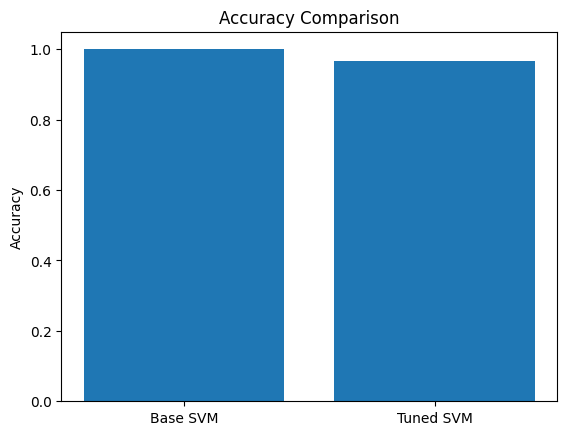

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# ======================
# LOAD DATASET
# ======================
df = pd.read_csv('IRIS.csv')

print("First 5 rows:")
print(df.head())

# ======================
# HANDLE CATEGORICAL DATA
# ======================
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# ======================
# SPLIT FEATURES & TARGET
# ======================
target = df.columns[-1]  # assumes last column is target
X = df.drop(target, axis=1)
y = df[target]

# ======================
# TRAIN TEST SPLIT
# ======================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ======================
# FEATURE SCALING
# ======================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ======================
# BASE SVM MODEL
# ======================
svm = SVC()
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)
print("\nBase Model Accuracy:", accuracy_score(y_test, y_pred))

# ======================
# HYPERPARAMETER TUNING
# ======================
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("\nBest Parameters:", grid.best_params_)

# ======================
# EVALUATE TUNED MODEL
# ======================
y_pred_best = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_best)
print("Tuned Model Accuracy:", accuracy)

# ======================
# CONFUSION MATRIX GRAPH
# ======================
cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm).plot()
plt.title("SVM Confusion Matrix")
plt.show()

# ======================
# ACCURACY COMPARISON GRAPH
# ======================
plt.figure()
plt.bar(["Base SVM", "Tuned SVM"],
        [accuracy_score(y_test, y_pred), accuracy])
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.show()